# Exp 4 — Intrinsic Dimension across Depth

Plots ID estimates (TwoNN / ESS) from `exp4_id_estimation` results.

**Depth convention:** 0 = post-attn block 0, 1 = post-FFN block 0, 2 = post-attn block 1, …

In [6]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Path to the HDF5 latent file produced by exp3
LATENTS_PATH = "../latents_d8_s16.h5"

# Path where exp4 JSONL results will be written (and read back for plotting)
RESULTS_PATH = "../results/exp4_n.jsonl"

# Token positions to analyse  (None → all tokens in the file)
TOKENS = None          # e.g. [0, 3, 7]

# User depths to analyse  (None → all block depths in the file)
DEPTHS = None          # e.g. [0, 1, 2, 3]

# Estimators to run / plot
METHODS = ["twonn", "ess"]
# ─────────────────────────────────────────────────────────────────────────────

In [12]:
import json
import subprocess
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

latents = Path(LATENTS_PATH)
results = Path(RESULTS_PATH)

# ── Read seq_len from the latents file so we know the valid token range ───────
with h5py.File(latents, "r") as f:
    _cfg = json.loads(f.attrs["config"])
    _seq_len  = _cfg["seq_len"]
    _n_layers = _cfg["n_layers"]

tokens = TOKENS if TOKENS is not None else list(range(_seq_len))
depths = DEPTHS if DEPTHS is not None else list(range(2 * _n_layers+2))

print(f"Latents : {latents}")
print(f"Results : {results}")
print(f"Tokens  : {tokens}")
print(f"Depths  : {depths}")
print(f"Methods : {METHODS}")

Latents : ../latents_d8_s16.h5
Results : ../results/exp4_n.jsonl
Tokens  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Depths  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Methods : ['twonn', 'ess']


In [13]:
# ── Load results ──────────────────────────────────────────────────────────────
rows = [json.loads(l) for l in results.read_text().splitlines() if l.strip()]

# Filter to the tokens/depths/methods selected above
rows = [
    r for r in rows
    if r["token_id"] in tokens and r["depth"] in depths
]

# Build lookup: (token_id, depth) → {method: id_value}
data: dict[tuple[int, int], dict[str, float]] = {}
for r in rows:
    key = (r["token_id"], r["depth"])
    data.setdefault(key, {})
    for m in METHODS:
        v = r.get(f"id_{m}")
        if v is not None:
            data[key][m] = v

print(f"Loaded {len(rows)} rows covering {len(tokens)} token(s) × {len(depths)} depth(s)")

Loaded 160 rows covering 16 token(s) × 10 depth(s)


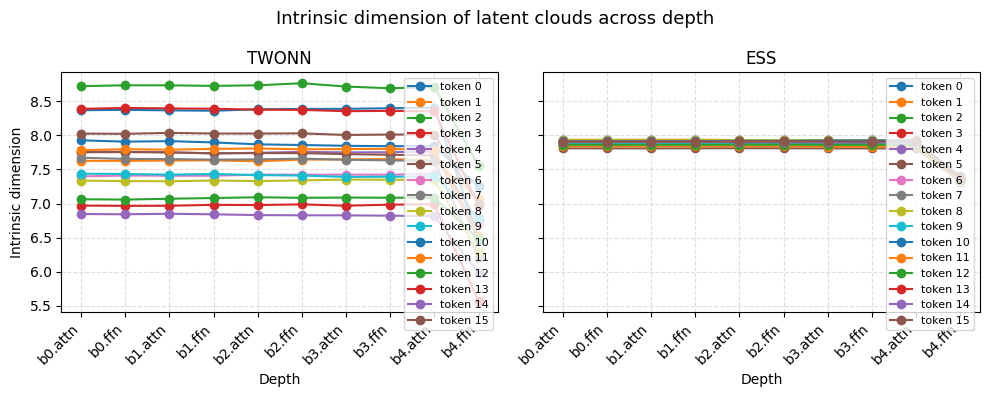

In [14]:
# ── Depth labels (block0.attn, block0.ffn, …) ─────────────────────────────────
def depth_label(d: int) -> str:
    block, sub = divmod(d, 2)
    return f"b{block}.{'attn' if sub == 0 else 'ffn'}"

depth_labels = [depth_label(d) for d in depths]
x = np.arange(len(depths))

# ── Plot ──────────────────────────────────────────────────────────────────────
n_methods = len(METHODS)
fig, axes = plt.subplots(
    1, n_methods,
    figsize=(5 * n_methods, 4),
    sharey=True,
    squeeze=False,
)

cmap = plt.get_cmap("tab10")

for col, method in enumerate(METHODS):
    ax = axes[0][col]
    for i, tok in enumerate(tokens):
        y = [data.get((tok, d), {}).get(method, float("nan")) for d in depths]
        ax.plot(x, y, marker="o", label=f"token {tok}", color=cmap(i % 10))

    ax.set_title(method.upper())
    ax.set_xticks(x)
    ax.set_xticklabels(depth_labels, rotation=45, ha="right")
    ax.set_xlabel("Depth")
    ax.set_ylabel("Intrinsic dimension" if col == 0 else "")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Intrinsic dimension of latent clouds across depth", fontsize=13)
plt.tight_layout()
plt.show()

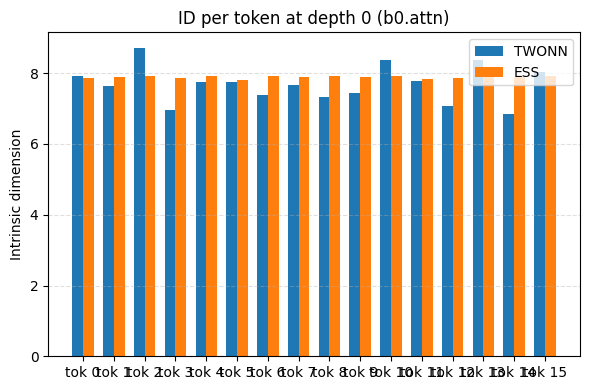

In [10]:
# ── Token comparison at a fixed depth ─────────────────────────────────────────
COMPARE_DEPTH = depths[0]   # ← change to any depth of interest

fig, ax = plt.subplots(figsize=(6, 4))
bar_w = 0.35
xb = np.arange(len(tokens))

for j, method in enumerate(METHODS):
    y = [data.get((tok, COMPARE_DEPTH), {}).get(method, float("nan")) for tok in tokens]
    ax.bar(xb + j * bar_w, y, bar_w, label=method.upper())

ax.set_title(f"ID per token at depth {COMPARE_DEPTH} ({depth_label(COMPARE_DEPTH)})")
ax.set_xticks(xb + bar_w / 2)
ax.set_xticklabels([f"tok {t}" for t in tokens])
ax.set_ylabel("Intrinsic dimension")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()